## Paddle OCR

### runtime to T4 GPU

In [3]:
!nvidia-smi

Fri Sep 25 09:28:23 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

In [4]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2025 NVIDIA Corporation
Built on Fri_Feb_21_20:23:50_PST_2025
Cuda compilation tools, release 12.8, V12.8.93
Build cuda_12.8.r12.8/compiler.35583870_0


In [5]:
!python -m pip install paddlepaddle-gpu==3.2.2 -i https://www.paddlepaddle.org.cn/packages/stable/cu129/
!pip install -q "paddleocr"
!pip install -q transformers torch torchvision
!pip install -q faiss-cpu rapidfuzz opencv-python pillow requests

Looking in indexes: https://www.paddlepaddle.org.cn/packages/stable/cu129/
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 GB 581.9 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 6.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.6/89.6 MB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 3.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.4/781.4 MB 524.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 580.7/580.7 MB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.9/200.9 MB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 MB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.8/331.8 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 366.4/366.4 MB ? eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322

In [6]:
import paddle
print("Paddle version:", paddle.__version__)
print("Compiled with CUDA:", paddle.device.is_compiled_with_cuda())
print("Device:", paddle.device.get_device())
paddle.utils.run_check()

/usr/local/lib/python3.13/dist-packages/paddle/utils/cpp_extension/extension_utils.py:718: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)


Paddle version: 3.2.2
Compiled with CUDA: True
Device: gpu:0
Running verify PaddlePaddle program ... 


/usr/local/lib/python3.13/dist-packages/paddle/pir/math_op_patch.py:219: UserWarning: Value do not have 'place' interface for pir graph mode, try not to use it. None will be returned.
  warnings.warn(


PaddlePaddle works well on 1 GPU.
PaddlePaddle is installed successfully! Let's start deep learning with PaddlePaddle now.


### Load PaddleOCR

In [7]:
from paddleocr import PaddleOCR

ocr = PaddleOCR(use_textline_orientation=True, lang="en")
print("PaddleOCR loaded ✅")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.
Using official model (PP-LCNet_x1_0_doc_ori), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 6 files:   0%|          | 0/6 [00:00<?, ?it/s]

Creating model: ('UVDoc', None, None)
Using official model (UVDoc), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/UVDoc`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Creating model: ('PP-OCRv6_medium_rec', None, None)
Using official model (PP-OCRv6_medium_rec), the model files will be automatically downloaded and saved in `/root/.paddlex/official_models/PP-OCRv6_medium_rec`.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

PaddleOCR loaded ✅


## Fetch a test card from the API

In [8]:
import requests
r = requests.get("https://api.tcgdex.net/v2/en/cards/base1-4", timeout=10)
print("Status:", r.status_code)
print("Name:", r.json().get("name"))

Status: 200
Name: Charizard


## PaddleOCR on the card

In [10]:
img_path = "/content/test_card.png"

result = ocr.ocr(img_path)

print("=== Raw OCR output ===\n")

# PaddleOCR v3 changed output format — handle both old and new
if isinstance(result, list) and len(result) > 0:
    page = result[0]

    # v3 format: dict with 'rec_texts' and 'rec_scores'
    if isinstance(page, dict):
        texts = page.get("rec_texts", [])
        scores = page.get("rec_scores", [])
        for text, conf in zip(texts, scores):
            print(f"  {text:40s}  conf={conf:.2f}")

    # older format: list of [bbox, (text, conf)]
    else:
        for line in page:
            bbox, (text, confidence) = line
            print(f"  {text:40s}  conf={confidence:.2f}")

/tmp/ipykernel_2165/2507441853.py:3: DeprecationWarning: Please use `predict` instead.
  result = ocr.ocr(img_path)


=== Raw OCR output ===

  STAGE 2                                   conf=1.00
  Evolves from Charmeleon                   conf=1.00
  Put Charizard on the Stage I card         conf=0.98
  Charizard                                 conf=1.00
  120 HP                                    conf=0.95
  Flame Pokémon. Length: 5' 7", Weight: 200 Ibs.  conf=1.00
  Pokémon Power: Energy Burn As often as you  conf=1.00
  like during your turn (before your attack), you may turn  conf=0.99
  all Energy attached to Charizard intoEnergy for the  conf=1.00
  rest of the turn.This power can't be used if Charizard  conf=0.98
  is Asleep, Confused, or Paralyzed.        conf=0.99
  Fire Spin Discard 2 Energy cards attached  conf=0.98
  100                                       conf=1.00
  to Charizard in order to use this attack.  conf=1.00
  weakness                                  conf=1.00
  resistance                                conf=1.00
  retreat cost                              conf=1.00
  -30  

In [14]:
# Load a French-language OCR since your cards are in French
from paddleocr import PaddleOCR
ocr_fr = PaddleOCR(use_textline_orientation=True, lang="french")
print("French PaddleOCR loaded ✅")

binder_path = "/content/classeur.webp"   #

result = ocr_fr.predict(binder_path)   # note: predict, not ocr

# Parse output
page = result[0]
texts = page.get("rec_texts", [])
scores = page.get("rec_scores", [])

print(f"\n=== Found {len(texts)} text regions ===\n")
for text, conf in zip(texts, scores):
    if conf > 0.85:                    # filter low-confidence noise
        print(f"  [{conf:.2f}]  {text}")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP

French PaddleOCR loaded ✅

=== Found 124 text regions ===

  [1.00]  Palkia
  [1.00]  130
  [1.00]  Zacian
  [1.00]  120
  [0.96]  BASE
  [1.00]  Groudon
  [1.00]  130
  [0.95]  **
  [1.00]  Téléportation Explosive 30
  [1.00]  Rugissement de Fer
  [1.00]  30
  [1.00]  Puissance Grandissante
  [0.99]  Vous pouvez échanger ce Pokémon contre l'un de vos
  [0.97]  Attachez une carte Énergie  de base de votre pile de
  [0.94]  Attachez une carte Énergie de base de votre main à lun
  [0.98]  Pokémon de Banc.
  [0.97]  défausse à l'un de vos Pokémon de Banc.
  [0.96]  de vos Pokemon.
  [1.00]  Compteur de Récompense 80+
  [1.00]  130
  [1.00]  Nettoyage Magma
  [0.97]  60×
  [0.89]  **
  [1.00]  Lame Vaillante
  [0.99]  S'll vous reste plus de cartes Récompense qu'à votre
  [1.00]  Pendant votre prochain tour, ce Pokémon ne peut pas
  [0.98]  Défaussez jusqu'à 4 Énergies de vos Pokémon. Cette
  [0.94]  adversaire, cette attaque inflige 80 degits supplémentaires
  [0.98]  attaquer.
  [0.97]  

## English OCR on this binder

In [15]:
# Switch back to English OCR
from paddleocr import PaddleOCR
ocr_en = PaddleOCR(use_textline_orientation=True, lang="en")
print("English PaddleOCR loaded ✅")

binder_path = "/content/binder_vintage.webp"   # ⚠️ change to your filename

result = ocr_en.predict(binder_path)

# Parse output
page = result[0]
texts = page.get("rec_texts", [])
scores = page.get("rec_scores", [])

print(f"\n=== Found {len(texts)} text regions ===\n")

# Print only high-confidence lines
for text, conf in zip(texts, scores):
    if conf > 0.85:
        print(f"  [{conf:.2f}]  {text}")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP

English PaddleOCR loaded ✅

=== Found 164 text regions ===

  [0.97]  Evolves from Irysour
  [1.00]  Bulbasaur
  [0.93]  40 HP
  [0.99]  Ivysaur
  [0.97]  60 HP
  [1.00]  Venusaur
  [0.98]  100 HP
  [0.91]  Seed Pokémon. Length: 2 4", Weight: 15 Ibs.
  [0.96]  Seed Pokémon. Length: 3' 3", Weight: 29 Ibs.
  [0.92]  Seed Pokémon. Length: 6' 7", Weight: 221 bs.
  [1.00]  Vine Whip
  [1.00]  30
  [0.85]  you like during your tum (before your aock, you may
  [1.00]  Leech Seed Unless all damage
  [0.90]  take I  Energy card attached to I of youl Pokémon
  [1.00]  from this attack is prevented, you
  [1.00]  20
  [0.99]  and attach it to a different one. This power can't be
  [0.94]  used if Venusaur is Aslee, Confused, or Paralyzed
  [0.99]  may remove I damage counter
  [0.99]  from Bulbasaur.
  [1.00]  Poisonpowder The Defending
  [1.00]  20
  [1.00]  Solarbeam
  [1.00]  60
  [1.00]  Pokémon is now Poisoned.
  [0.95]  resivtance
  [1.00]  retreat cost
  [1.00]  reakness
  [1.00]  resistan

## Test the Pokémon TCG API

In [16]:
import requests

# Try TCGdex — search for Charizard in the base set
url = "https://api.tcgdex.net/v2/en/cards"
response = requests.get(url + "?name=Charizard", timeout=10)

print("Status:", response.status_code)
print("Content-Type:", response.headers.get("Content-Type"))

if response.status_code == 200:
    data = response.json()
    print(f"\nTotal results: {len(data)}")
    print("First 5:")
    for card in data[:5]:
        print(f"  {card}")
else:
    print("Response text:", response.text[:300])

Status: 200
Content-Type: application/json; charset=utf-8

Total results: 126
First 5:
  {'id': '2024sv-1', 'localId': '1', 'name': 'Charizard'}
  {'id': '30th-c-001', 'localId': '001', 'name': 'Charizard'}
  {'id': 'pl4-1', 'localId': '1', 'name': 'Charizard', 'image': 'https://assets.tcgdex.net/en/pl/pl4/1'}
  {'id': 'gym2-2', 'localId': '2', 'name': "Blaine's Charizard", 'image': 'https://assets.tcgdex.net/en/gym/gym2/2'}
  {'id': 'sm7.5-3', 'localId': '3', 'name': 'Charizard'}


In [17]:
# Get details on Base Set Charizard specifically
card_id = "base1-4"   # Base Set (base1) card #4
r = requests.get(f"https://api.tcgdex.net/v2/en/cards/{card_id}", timeout=10)
card = r.json()

print("=== Available fields ===")
for key, value in card.items():
    if isinstance(value, (str, int, float, bool)):
        print(f"  {key}: {value}")
    elif isinstance(value, list):
        print(f"  {key}: list of {len(value)} items")
    elif isinstance(value, dict):
        print(f"  {key}: dict with keys {list(value.keys())}")

=== Available fields ===
  category: Pokemon
  id: base1-4
  illustrator: Mitsuhiro Arita
  image: https://assets.tcgdex.net/en/base/base1/4
  localId: 4
  name: Charizard
  rarity: Rare
  set: dict with keys ['cardCount', 'id', 'logo', 'name']
  variants: dict with keys ['firstEdition', 'holo', 'normal', 'reverse', 'wPromo']
  variants_detailed: list of 4 items
  dexId: list of 1 items
  hp: 120
  types: list of 1 items
  evolveFrom: Charmeleon
  description: Spits fire that is hot enough to melt boulders. Known to unintentionally cause forest fires.
  stage: Stage2
  abilities: list of 1 items
  attacks: list of 1 items
  weaknesses: list of 1 items
  resistances: list of 1 items
  retreat: 3
  legal: dict with keys ['standard', 'expanded']
  updated: 2026-09-04T23:45:25+01:00
  pricing: dict with keys ['cardmarket', 'tcgplayer']


## Inspect the important lists

In [18]:
import json

# Look at attacks
print("=== Attacks ===")
print(json.dumps(card["attacks"], indent=2))

print("\n=== Abilities ===")
print(json.dumps(card["abilities"], indent=2))

print("\n=== Set info ===")
print(json.dumps(card["set"], indent=2))

print("\n=== Types + Weaknesses ===")
print("types:", card["types"])
print("weaknesses:", json.dumps(card["weaknesses"], indent=2))

=== Attacks ===
[
  {
    "cost": [
      "Fire",
      "Fire",
      "Fire",
      "Fire"
    ],
    "name": "Fire Spin",
    "effect": "Discard 2 Energy cards attached to Charizard in order to use this attack.",
    "damage": 100
  }
]

=== Abilities ===
[
  {
    "type": "Pokemon Power",
    "name": "Energy Burn",
    "effect": "As often as you like during your turn (before your attack), you may turn all Energy attached to Charizard into Fire Energy for the rest of the turn. This power can't be used if Charizard is Asleep, Confused, or Paralyzed."
  }
]

=== Set info ===
{
  "cardCount": {
    "official": 102,
    "total": 102
  },
  "id": "base1",
  "logo": "https://assets.tcgdex.net/en/base/base1/logo",
  "name": "Base Set"
}

=== Types + Weaknesses ===
types: ['Fire']
weaknesses: [
  {
    "type": "Water",
    "value": "\u00d72"
  }
]


## Test the name search endpoint

In [19]:
# Search all cards named Charizard
r = requests.get("https://api.tcgdex.net/v2/en/cards?name=Charizard", timeout=15)
results = r.json()

print(f"Total Charizards: {len(results)}\n")
print("First 10:")
for c in results[:10]:
    print(f"  id={c.get('id'):20s}  {c.get('name'):15s}  localId={c.get('localId', '?')}")

Total Charizards: 126

First 10:
  id=2024sv-1              Charizard        localId=1
  id=30th-c-001            Charizard        localId=001
  id=pl4-1                 Charizard        localId=1
  id=gym2-2                Blaine's Charizard  localId=2
  id=sm7.5-3               Charizard        localId=3
  id=lc-3                  Charizard        localId=3
  id=dp3-3                 Charizard        localId=3
  id=base4-4               Charizard        localId=4
  id=base1-4               Charizard        localId=4
  id=base5-4               Dark Charizard   localId=4


In [20]:
import requests
import re
from rapidfuzz import fuzz

BASE = "https://api.tcgdex.net/v2/en"

def get_card_candidates(name, timeout=15):
    """Search by name, return only exact-name matches."""
    r = requests.get(f"{BASE}/cards", params={"name": name}, timeout=timeout)
    all_hits = r.json()
    # Filter to exact name matches (case-insensitive)
    return [c for c in all_hits if c["name"].lower() == name.lower()]


def fetch_card_details(card_id, timeout=15):
    """Get full data for one card."""
    r = requests.get(f"{BASE}/cards/{card_id}", timeout=timeout)
    return r.json()


def score_candidate(candidate, ocr_data):
    """Score how well a candidate matches OCR data. Returns 0-100."""
    score = 0
    reasons = []

    # HP match (worth 30 points)
    if ocr_data.get("hp") and candidate.get("hp"):
        if str(ocr_data["hp"]) == str(candidate["hp"]):
            score += 30
            reasons.append(f"HP match ({candidate['hp']})")

    # Attack name matches (worth up to 40 points)
    ocr_attacks = [a.lower() for a in ocr_data.get("attacks", [])]
    cand_attacks = [a["name"].lower() for a in candidate.get("attacks", [])]

    for ocr_atk in ocr_attacks:
        best = max((fuzz.ratio(ocr_atk, ca) for ca in cand_attacks), default=0)
        if best > 85:
            score += 20
            reasons.append(f"Attack '{ocr_atk}' matches")

    # Ability name matches (worth 20 points)
    ocr_abilities = [a.lower() for a in ocr_data.get("abilities", [])]
    cand_abilities = [a["name"].lower() for a in candidate.get("abilities", [])]

    for ocr_ab in ocr_abilities:
        best = max((fuzz.ratio(ocr_ab, ca) for ca in cand_abilities), default=0)
        if best > 85:
            score += 20
            reasons.append(f"Ability '{ocr_ab}' matches")

    # Set number match (worth 30 points, super strong signal when present)
    if ocr_data.get("set_number"):
        # OCR gives us something like "4/102"
        match = re.match(r"(\d+)\s*/\s*(\d+)", ocr_data["set_number"])
        if match:
            ocr_num, ocr_total = match.groups()
            cand_num = str(candidate.get("localId", "")).lstrip("0") or "0"
            cand_total = str(candidate.get("set", {}).get("cardCount", {}).get("official", ""))
            if ocr_num.lstrip("0") == cand_num and ocr_total == cand_total:
                score += 30
                reasons.append(f"Set number match ({ocr_num}/{ocr_total})")

    return score, reasons


def identify_card(ocr_data, verbose=True):
    """
    Take OCR data for one card and return the best-matched card ID.

    ocr_data = {
        "name": "Charizard",
        "hp": "120",
        "attacks": ["Fire Spin"],
        "abilities": ["Energy Burn"],
        "set_number": "4/102"     # optional, if OCR read it
    }
    """
    name = ocr_data["name"]
    candidates = get_card_candidates(name)

    if verbose:
        print(f"Found {len(candidates)} exact-name matches for '{name}'")

    if not candidates:
        return None

    # Fetch details for each candidate and score
    scored = []
    for i, cand in enumerate(candidates):
        try:
            details = fetch_card_details(cand["id"])
            score, reasons = score_candidate(details, ocr_data)
            scored.append((score, details, reasons))
            if verbose and score > 0:
                print(f"  [{score:3d}] {cand['id']:20s} — {', '.join(reasons)}")
        except Exception as e:
            print(f"  Error fetching {cand['id']}: {e}")

    scored.sort(key=lambda x: x[0], reverse=True)

    if not scored or scored[0][0] == 0:
        return None

    best_score, best_card, best_reasons = scored[0]
    return {
        "id": best_card["id"],
        "name": best_card["name"],
        "set": best_card["set"]["name"],
        "number": f"{best_card['localId']}/{best_card['set']['cardCount']['official']}",
        "hp": best_card.get("hp"),
        "confidence": best_score,
        "matched_on": best_reasons,
    }

In [21]:
# Simulate what OCR gave us for the Charizard card from the vintage binder
ocr_charizard = {
    "name": "Charizard",
    "hp": "120",
    "attacks": ["Fire Spin"],
    "abilities": ["Energy Burn"],
    # We intentionally leave set_number empty since OCR missed it
    # (this tests whether HP + attacks + abilities alone are enough)
}

print("=== Testing matcher on Charizard (no set number) ===\n")
result = identify_card(ocr_charizard)

print("\n=== BEST MATCH ===")
print(result)

=== Testing matcher on Charizard (no set number) ===

Found 32 exact-name matches for 'Charizard'
  [ 70] 30th-c-001           — HP match (120), Attack 'fire spin' matches, Ability 'energy burn' matches
  [ 70] lc-3                 — HP match (120), Attack 'fire spin' matches, Ability 'energy burn' matches
  [ 70] base4-4              — HP match (120), Attack 'fire spin' matches, Ability 'energy burn' matches
  [ 70] base1-4              — HP match (120), Attack 'fire spin' matches, Ability 'energy burn' matches
  [ 30] ecard1-6             — HP match (120)
  [ 30] ex16-6               — HP match (120)
  [ 40] xy12-11              — Attack 'fire spin' matches, Ability 'energy burn' matches
  [ 20] A1-035               — Attack 'fire spin' matches
  [ 30] ecard1-40            — HP match (120)
  [ 30] ex3-100              — HP match (120)
  [ 70] dp7-103              — HP match (120), Attack 'fire spin' matches, Ability 'energy burn' matches
  [ 70] cel25cc-CC002        — HP match (120),

In [22]:
def score_candidate(candidate, ocr_data):
    """Score how well a candidate matches OCR data. Returns 0-100."""
    score = 0
    reasons = []

    # --- HP match (30 pts) ---
    if ocr_data.get("hp") and candidate.get("hp"):
        if str(ocr_data["hp"]) == str(candidate["hp"]):
            score += 30
            reasons.append(f"HP={candidate['hp']}")

    # --- Attack name matches (up to 40 pts) ---
    ocr_attacks = [a.lower() for a in ocr_data.get("attacks", [])]
    cand_attacks = [a["name"].lower() for a in candidate.get("attacks", [])]
    for ocr_atk in ocr_attacks:
        best = max((fuzz.ratio(ocr_atk, ca) for ca in cand_attacks), default=0)
        if best > 85:
            score += 20
            reasons.append(f"atk:{ocr_atk}")

    # --- Ability name matches (20 pts) ---
    ocr_abilities = [a.lower() for a in ocr_data.get("abilities", [])]
    cand_abilities = [a["name"].lower() for a in candidate.get("abilities", [])]
    for ocr_ab in ocr_abilities:
        best = max((fuzz.ratio(ocr_ab, ca) for ca in cand_abilities), default=0)
        if best > 85:
            score += 20
            reasons.append(f"ab:{ocr_ab}")

    # --- Set number match (up to 60 pts, split into card# and total#) ---
    if ocr_data.get("set_number"):
        match = re.match(r"(\d+)\s*/\s*(\d+)", ocr_data["set_number"])
        if match:
            ocr_num, ocr_total = match.groups()
            cand_num_raw = str(candidate.get("localId", "")).lstrip("0") or "0"
            ocr_num_stripped = ocr_num.lstrip("0") or "0"

            # Get set total, falling back through possible fields
            cc = candidate.get("set", {}).get("cardCount", {})
            cand_total = str(cc.get("official") or cc.get("total") or "")

            if ocr_num_stripped == cand_num_raw:
                score += 30
                reasons.append(f"num#{ocr_num}")
            if cand_total and ocr_total == cand_total:
                score += 30
                reasons.append(f"total/{ocr_total}")

    return score, reasons


def identify_card(ocr_data, verbose=True):
    name = ocr_data["name"]
    candidates = get_card_candidates(name)

    if verbose:
        print(f"Found {len(candidates)} exact-name matches for '{name}'")

    if not candidates:
        return None

    scored = []
    for cand in candidates:
        try:
            details = fetch_card_details(cand["id"])
            score, reasons = score_candidate(details, ocr_data)
            scored.append((score, details, reasons))
        except Exception as e:
            print(f"  Error fetching {cand['id']}: {e}")

    scored.sort(key=lambda x: x[0], reverse=True)

    if verbose:
        print("\nTop 5 candidates:")
        for score, card, reasons in scored[:5]:
            print(f"  [{score:3d}] {card['id']:22s} {card['set']['name']:35s} {reasons}")

    if not scored or scored[0][0] == 0:
        return None

    best_score, best_card, best_reasons = scored[0]
    cc = best_card["set"].get("cardCount", {})
    total = cc.get("official") or cc.get("total") or "?"

    return {
        "id": best_card["id"],
        "name": best_card["name"],
        "set": best_card["set"]["name"],
        "number": f"{best_card['localId']}/{total}",
        "hp": best_card.get("hp"),
        "confidence": best_score,
        "matched_on": best_reasons,
    }

In [23]:
# Now include the set number as OCR would give it
ocr_charizard = {
    "name": "Charizard",
    "hp": "120",
    "attacks": ["Fire Spin"],
    "abilities": ["Energy Burn"],
    "set_number": "4/102",     # ← this is the killer signal
}

print("=== Testing WITH set number 4/102 ===\n")
result = identify_card(ocr_charizard)

print("\n=== BEST MATCH ===")
print(result)

=== Testing WITH set number 4/102 ===

Found 32 exact-name matches for 'Charizard'

Top 5 candidates:
  [130] base1-4                Base Set                            ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4', 'total/102']
  [100] base4-4                Base Set 2                          ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4']
  [ 70] 30th-c-001             30th Classic Collection             ['HP=120', 'atk:fire spin', 'ab:energy burn']
  [ 70] lc-3                   Legendary Collection                ['HP=120', 'atk:fire spin', 'ab:energy burn']
  [ 70] dp7-103                Stormfront                          ['HP=120', 'atk:fire spin', 'ab:energy burn']

=== BEST MATCH ===
{'id': 'base1-4', 'name': 'Charizard', 'set': 'Base Set', 'number': '4/102', 'hp': 120, 'confidence': 130, 'matched_on': ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4', 'total/102']}


In [24]:
import requests
import re
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from rapidfuzz import fuzz

BASE = "https://api.tcgdex.net/v2/en"

# --- Local caches ---
_search_cache = {}    # name → list of candidates
_detail_cache = {}    # card_id → full details


def get_card_candidates(name, timeout=15):
    """Search by exact name, with caching."""
    key = name.lower()
    if key in _search_cache:
        return _search_cache[key]

    r = requests.get(f"{BASE}/cards", params={"name": name}, timeout=timeout)
    all_hits = r.json()
    exact = [c for c in all_hits if c["name"].lower() == key]
    _search_cache[key] = exact
    return exact


def fetch_card_details(card_id, timeout=15):
    """Fetch full details for one card, with caching."""
    if card_id in _detail_cache:
        return _detail_cache[card_id]

    r = requests.get(f"{BASE}/cards/{card_id}", timeout=timeout)
    r.raise_for_status()
    data = r.json()
    _detail_cache[card_id] = data
    return data


def fetch_many_parallel(card_ids, max_workers=10):
    """Fetch multiple card details concurrently."""
    results = {}
    with ThreadPoolExecutor(max_workers=max_workers) as executor:
        future_to_id = {
            executor.submit(fetch_card_details, cid): cid
            for cid in card_ids
        }
        for future in as_completed(future_to_id):
            cid = future_to_id[future]
            try:
                results[cid] = future.result()
            except Exception as e:
                print(f"  ⚠️  Failed {cid}: {e}")
    return results

In [25]:
def score_candidate(candidate, ocr_data):
    score = 0
    reasons = []

    # HP match (30 pts)
    if ocr_data.get("hp") and candidate.get("hp"):
        if str(ocr_data["hp"]) == str(candidate["hp"]):
            score += 30
            reasons.append(f"HP={candidate['hp']}")

    # Attack name matches (20 pts each)
    ocr_attacks = [a.lower() for a in ocr_data.get("attacks", [])]
    cand_attacks = [a["name"].lower() for a in candidate.get("attacks", [])]
    for ocr_atk in ocr_attacks:
        best = max((fuzz.ratio(ocr_atk, ca) for ca in cand_attacks), default=0)
        if best > 85:
            score += 20
            reasons.append(f"atk:{ocr_atk}")

    # Ability name matches (20 pts each)
    ocr_abilities = [a.lower() for a in ocr_data.get("abilities", [])]
    cand_abilities = [a["name"].lower() for a in candidate.get("abilities", [])]
    for ocr_ab in ocr_abilities:
        best = max((fuzz.ratio(ocr_ab, ca) for ca in cand_abilities), default=0)
        if best > 85:
            score += 20
            reasons.append(f"ab:{ocr_ab}")

    # Set number match (30 + 30 pts)
    if ocr_data.get("set_number"):
        m = re.match(r"(\d+)\s*/\s*(\d+)", ocr_data["set_number"])
        if m:
            ocr_num, ocr_total = m.groups()
            cand_num_raw = str(candidate.get("localId", "")).lstrip("0") or "0"
            ocr_num_stripped = ocr_num.lstrip("0") or "0"
            cc = candidate.get("set", {}).get("cardCount", {})
            cand_total = str(cc.get("official") or cc.get("total") or "")
            if ocr_num_stripped == cand_num_raw:
                score += 30
                reasons.append(f"num#{ocr_num}")
            if cand_total and ocr_total == cand_total:
                score += 30
                reasons.append(f"total/{ocr_total}")

    return score, reasons


def identify_card(ocr_data, verbose=True):
    name = ocr_data["name"]
    candidates = get_card_candidates(name)

    if verbose:
        print(f"Found {len(candidates)} exact-name matches for '{name}'")

    if not candidates:
        return None

    # Parallel fetch all candidate details
    t0 = time.time()
    card_ids = [c["id"] for c in candidates]
    details_map = fetch_many_parallel(card_ids, max_workers=10)
    fetch_time = time.time() - t0
    if verbose:
        print(f"Fetched {len(details_map)} details in {fetch_time:.1f}s")

    # Score all candidates
    scored = []
    for cid, details in details_map.items():
        score, reasons = score_candidate(details, ocr_data)
        scored.append((score, details, reasons))

    scored.sort(key=lambda x: x[0], reverse=True)

    if verbose:
        print("\nTop 3 candidates:")
        for score, card, reasons in scored[:3]:
            print(f"  [{score:3d}] {card['id']:22s} {card['set']['name']:35s} {reasons}")

    if not scored or scored[0][0] == 0:
        return None

    best_score, best_card, best_reasons = scored[0]
    cc = best_card["set"].get("cardCount", {})
    total = cc.get("official") or cc.get("total") or "?"

    return {
        "id": best_card["id"],
        "name": best_card["name"],
        "set": best_card["set"]["name"],
        "number": f"{best_card['localId']}/{total}",
        "hp": best_card.get("hp"),
        "confidence": best_score,
        "matched_on": best_reasons,
    }

In [26]:
ocr_charizard = {
    "name": "Charizard",
    "hp": "120",
    "attacks": ["Fire Spin"],
    "abilities": ["Energy Burn"],
    "set_number": "4/102",
}

print("=" * 60)
print("FIRST CALL (cold cache — all 32 cards fetched fresh)")
print("=" * 60)
t0 = time.time()
result = identify_card(ocr_charizard)
print(f"\n⏱️  Total time: {time.time() - t0:.1f}s")
print(f"Result: {result['id']} — {result['set']} #{result['number']}")

print("\n" + "=" * 60)
print("SECOND CALL (warm cache — everything already fetched)")
print("=" * 60)
t0 = time.time()
result = identify_card(ocr_charizard)
print(f"\n⏱️  Total time: {time.time() - t0:.1f}s")
print(f"Result: {result['id']} — {result['set']} #{result['number']}")

FIRST CALL (cold cache — all 32 cards fetched fresh)
Found 32 exact-name matches for 'Charizard'
Fetched 32 details in 0.9s

Top 3 candidates:
  [130] base1-4                Base Set                            ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4', 'total/102']
  [100] base4-4                Base Set 2                          ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4']
  [ 70] 30th-c-001             30th Classic Collection             ['HP=120', 'atk:fire spin', 'ab:energy burn']

⏱️  Total time: 1.2s
Result: base1-4 — Base Set #4/102

SECOND CALL (warm cache — everything already fetched)
Found 32 exact-name matches for 'Charizard'
Fetched 32 details in 0.0s

Top 3 candidates:
  [130] base1-4                Base Set                            ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4', 'total/102']
  [100] base4-4                Base Set 2                          ['HP=120', 'atk:fire spin', 'ab:energy burn', 'num#4']
  [ 70] 30th-c-001           

In [27]:
import re

def parse_ocr_to_card_data(ocr_texts):
    data = {
        "name": None,
        "hp": None,
        "attacks": [],
        "abilities": [],
        "set_number": None,
    }

    joined = " ".join(ocr_texts)

    # --- HP ---
    hp_match = re.search(r"(\d{2,3})\s*(?:HP|H\b|PV)", joined, re.IGNORECASE)
    if not hp_match:
        hp_match = re.search(r"(?:HP|PV)\s*(\d{2,3})", joined, re.IGNORECASE)
    if hp_match:
        data["hp"] = hp_match.group(1)

    # --- Set number ---
    num_match = re.search(r"\b(\d{1,3})\s*/\s*(\d{1,3})\b", joined)
    if num_match:
        data["set_number"] = f"{num_match.group(1)}/{num_match.group(2)}"

    # --- Abilities ---
    ability_keywords = [
        "Pokémon Power:", "Pokemon Power:",
        "Poké-Power:", "Poke-Power:",
        "Ability:", "Talent:",
    ]
    stop_words = {"as", "once", "when", "if", "the", "your", "you", "this",
                  "during", "at", "whenever", "each", "flip", "count", "for"}

    for text in ocr_texts:
        for kw in ability_keywords:
            if kw.lower() in text.lower():
                idx = text.lower().find(kw.lower()) + len(kw)
                rest = text[idx:].strip()
                words = rest.split()
                ability_name_words = []
                for w in words[:6]:
                    if w.lower().strip(".,") in stop_words and ability_name_words:
                        break
                    if w[0].islower() and ability_name_words:
                        break
                    ability_name_words.append(w)
                if ability_name_words:
                    data["abilities"].append(" ".join(ability_name_words).rstrip(".,"))
                break

    # --- Attacks ---
    skip_words = {
        "BASE", "STAGE", "Basic", "Evolves", "Put", "Illus",
        "Seed", "Lizard", "Turtle", "Tiny", "Shellfish", "Flame",
        "Talent", "Weakness", "Resistance", "Length", "Weight",
        "This", "The", "When", "Often", "After", "An", "A", "As", "If",
        "All", "During", "Spits",
        "Base", "Attachez", "Défaussez", "Pendant",
    }
    skip_line_if_contains = ["Pokémon Power", "Pokemon Power", "Ability:", "Talent:",
                              "Length", "Weight", "Illus.", "Evolves"]

    for text in ocr_texts:
        stripped = text.strip()
        if not stripped:
            continue
        if any(kw.lower() in stripped.lower() for kw in skip_line_if_contains):
            continue
        if len(stripped) > 60:
            continue

        m = re.match(r"^([A-ZÀ-Ý][a-zà-ÿ']*(?:[- ][A-ZÀ-Ý][a-zà-ÿ']*){0,1})\b", stripped)
        if m:
            candidate = m.group(1)
            first_word = candidate.split()[0]
            if first_word in skip_words:
                continue
            if len(candidate) < 4:
                continue
            if candidate not in data["attacks"]:
                data["attacks"].append(candidate)

    return data

print("Parser v2 loaded ✅")

Parser v2 loaded ✅


In [32]:
import cv2
import numpy as np
from PIL import Image
from IPython.display import display

def detect_binder_hybrid(image_path, rows=3, cols=3,
                          left_bound=0.05, right_bound=0.95,
                          debug=True):
    """
    Hybrid: detect rows with Hough lines, split columns evenly.
    left_bound/right_bound: where the card region starts/ends horizontally (fractions).
    """
    img = cv2.imread(image_path)
    h, w = img.shape[:2]

    # --- Row detection with Hough ---
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    edges = cv2.Canny(blurred, 40, 120)

    min_len_h = int(w * 0.3)
    lines = cv2.HoughLinesP(edges, 1, np.pi / 180, threshold=100,
                             minLineLength=min_len_h, maxLineGap=30)

    horiz_y = []
    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]
            if abs(y2 - y1) < 15 and abs(x2 - x1) > min_len_h:
                horiz_y.append((y1 + y2) // 2)

    def cluster_1d(coords, tolerance):
        if not coords:
            return []
        coords = sorted(coords)
        clusters = [[coords[0]]]
        for c in coords[1:]:
            if c - clusters[-1][-1] < tolerance:
                clusters[-1].append(c)
            else:
                clusters.append([c])
        return [int(np.mean(cl)) for cl in clusters]

    horiz_clustered = cluster_1d(horiz_y, tolerance=h * 0.05)

    # Pick evenly-spaced boundaries, including image top and bottom
    def pick_evenly_spaced(coords, needed, dim_size):
        candidates = sorted(set([0] + coords + [dim_size]))
        while len(candidates) > needed:
            gaps = [candidates[i+1] - candidates[i-1] for i in range(1, len(candidates)-1)]
            min_gap_idx = gaps.index(min(gaps)) + 1
            candidates.pop(min_gap_idx)
        return candidates

    h_lines = pick_evenly_spaced(horiz_clustered, rows + 1, h)

    # --- Column detection: math ---
    left_px = int(w * left_bound)
    right_px = int(w * right_bound)
    v_lines = [left_px + int((right_px - left_px) * i / cols) for i in range(cols + 1)]

    if debug:
        print(f"Horizontal boundaries: {h_lines}")
        print(f"Vertical boundaries: {v_lines}")

    # --- Crop cells ---
    crops = []
    overlay = img.copy()

    for y in h_lines:
        cv2.line(overlay, (0, y), (w, y), (255, 0, 0), 3)
    for x in v_lines:
        cv2.line(overlay, (x, 0), (x, h), (255, 0, 0), 3)

    idx = 1
    for r in range(rows):
        for c in range(cols):
            y1, y2 = h_lines[r], h_lines[r + 1]
            x1, x2 = v_lines[c], v_lines[c + 1]
            m = int(min(y2 - y1, x2 - x1) * 0.04)
            crop = img[y1+m:y2-m, x1+m:x2-m]
            crops.append(crop)
            cv2.rectangle(overlay, (x1+m, y1+m), (x2-m, y2-m), (0, 255, 0), 4)
            cv2.putText(overlay, str(idx), (x1+30, y1+80),
                        cv2.FONT_HERSHEY_SIMPLEX, 2, (0, 0, 255), 5)
            idx += 1

    if debug:
        overlay_small = cv2.resize(overlay, (600, int(600 * h / w)))
        display(Image.fromarray(cv2.cvtColor(overlay_small, cv2.COLOR_BGR2RGB)))
        print(f"\nCropped {len(crops)} cards")

    return crops

Horizontal boundaries: [0, 437, 876, 1440]
Vertical boundaries: [140, 417, 694, 972]


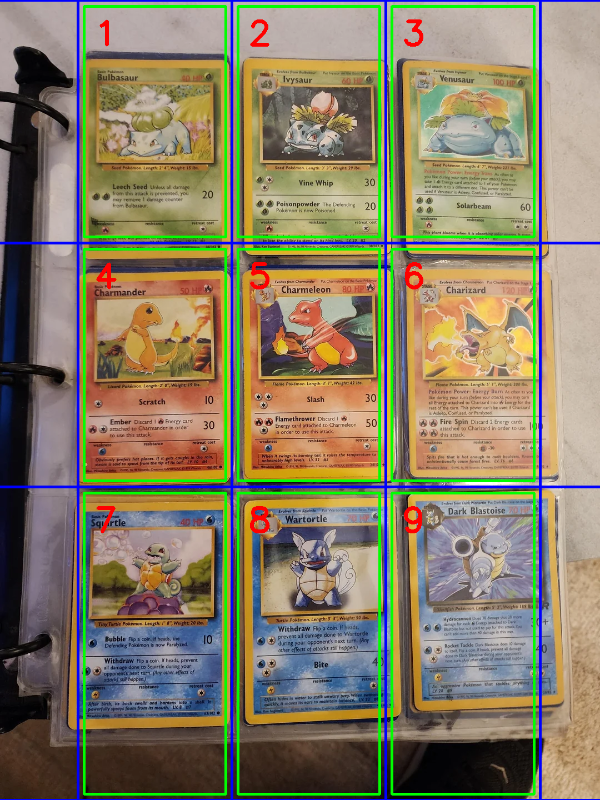


Cropped 9 cards


In [33]:
crops = detect_binder_hybrid(
    "/content/binder_vintage.webp",
    rows=3, cols=3,
    left_bound=0.13,
    right_bound=0.90,
    debug=True
)

In [34]:
import os
os.makedirs("/content/card_crops", exist_ok=True)

for i, crop in enumerate(crops):
    path = f"/content/card_crops/card_{i+1}.png"
    cv2.imwrite(path, crop)

print(f"✅ Saved {len(crops)} crops to /content/card_crops/")

✅ Saved 9 crops to /content/card_crops/


In [ ]:
from paddleocr import PaddleOCR

ocr_en = PaddleOCR(use_textline_orientation=True, lang="en")
print("English PaddleOCR loaded ✅")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_doc_ori`.
Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `/root/.paddlex/official_models/PP

English PaddleOCR loaded ✅


In [35]:
# Sets ranked by "canonical-ness" (earlier = higher priority when tied)
# You can extend this list based on what sets you own
CANONICAL_SET_PRIORITY = [
    "base1",       # Base Set (1999)
    "base2",       # Jungle
    "base3",       # Fossil
    "base4",       # Base Set 2
    "base5",       # Team Rocket
    "gym1", "gym2", "neo1", "neo2", "neo3", "neo4",
]

def identify_card(ocr_data, verbose=True):
    name = ocr_data["name"]
    candidates = get_card_candidates(name)

    if verbose:
        print(f"Found {len(candidates)} exact-name matches for '{name}'")
    if not candidates:
        return None

    card_ids = [c["id"] for c in candidates]
    details_map = fetch_many_parallel(card_ids, max_workers=10)

    scored = []
    for cid, details in details_map.items():
        score, reasons = score_candidate(details, ocr_data)
        # Add canonical-set bonus for tiebreaking
        set_id = details.get("set", {}).get("id", "")
        if set_id in CANONICAL_SET_PRIORITY:
            bonus = 10 - CANONICAL_SET_PRIORITY.index(set_id)  # 10 down to 0
            score += bonus
            reasons.append(f"canon+{bonus}")
        scored.append((score, details, reasons))

    scored.sort(key=lambda x: x[0], reverse=True)

    if verbose:
        print("\nTop 3 candidates:")
        for score, card, reasons in scored[:3]:
            print(f"  [{score:3d}] {card['id']:22s} {card['set']['name']:35s} {reasons}")

    if not scored or scored[0][0] == 0:
        return None

    best_score, best_card, best_reasons = scored[0]
    cc = best_card["set"].get("cardCount", {})
    total = cc.get("official") or cc.get("total") or "?"

    return {
        "id": best_card["id"],
        "name": best_card["name"],
        "set": best_card["set"]["name"],
        "number": f"{best_card['localId']}/{total}",
        "hp": best_card.get("hp"),
        "confidence": best_score,
        "matched_on": best_reasons,
    }

In [36]:
expected_names = [
    "Bulbasaur", "Ivysaur", "Venusaur",
    "Charmander", "Charmeleon", "Charizard",
    "Squirtle", "Wartortle", "Dark Blastoise",
]

print("=" * 70)
print("FULL PIPELINE — 9 CARDS")
print("=" * 70)

results = []

for i, crop in enumerate(crops):
    print(f"\n{'─' * 70}")
    print(f"Card {i+1}: expecting {expected_names[i]}")
    print(f"{'─' * 70}")

    crop_path = f"/content/card_crops/card_{i+1}.png"

    # 1. OCR
    ocr_result = ocr_en.predict(crop_path)
    texts = ocr_result[0].get("rec_texts", [])
    scores = ocr_result[0].get("rec_scores", [])

    # 2. Parse
    parsed = parse_ocr_to_card_data(texts)
    parsed["name"] = expected_names[i]   # hardcoded for now

    print(f"  Parsed: hp={parsed['hp']} | "
          f"attacks={parsed['attacks'][:3]} | "
          f"abilities={parsed['abilities']} | "
          f"set#={parsed['set_number']}")

    # 3. Match
    try:
        result = identify_card(parsed, verbose=False)
        if result:
            expected = expected_names[i]
            actual = result['name']
            correct = "✅" if actual.lower() == expected.lower() else "⚠️"
            print(f"  {correct} MATCH: {result['id']} — {result['set']} "
                  f"#{result['number']} (score: {result['confidence']})")
            results.append(result)
        else:
            print("  ❌ NO MATCH")
            results.append(None)
    except Exception as e:
        print(f"  ❌ ERROR: {e}")
        results.append(None)

# --- Summary ---
print("\n" + "=" * 70)
print("SUMMARY")
print("=" * 70)
matched = sum(1 for r in results if r)
print(f"\n{matched}/{len(results)} cards identified\n")

for i, (expected, r) in enumerate(zip(expected_names, results)):
    if r:
        print(f"  {i+1}. {expected:20s} → {r['set']} #{r['number']}")
    else:
        print(f"  {i+1}. {expected:20s} → ❌ FAILED")

FULL PIPELINE — 9 CARDS

──────────────────────────────────────────────────────────────────────
Card 1: expecting Bulbasaur
──────────────────────────────────────────────────────────────────────
  Parsed: hp=40 | attacks=['Bulbasaur', 'Leech Seed'] | abilities=[] | set#=None
  ✅ MATCH: base1-44 — Base Set #44/102 (score: 60)

──────────────────────────────────────────────────────────────────────
Card 2: expecting Ivysaur
──────────────────────────────────────────────────────────────────────
  Parsed: hp=60 | attacks=['Ivysaur', 'Vine Whip', 'Poisonpowder The'] | abilities=[] | set#=None
  ✅ MATCH: base1-30 — Base Set #30/102 (score: 80)

──────────────────────────────────────────────────────────────────────
Card 3: expecting Venusaur
──────────────────────────────────────────────────────────────────────
  Parsed: hp=100 | attacks=['Pve Yonusaur', 'Venusaur', 'Poliemon Power'] | abilities=[] | set#=None
  ✅ MATCH: base1-15 — Base Set #15/102 (score: 60)

────────────────────────────────

In [37]:
import re

def extract_card_name(ocr_result, crop_height, debug=False):
    """
    Extract the card name from PaddleOCR output of a single card crop.
    Uses bounding box positions to find the topmost, largest capitalized text.
    """
    page = ocr_result[0]
    texts = page.get("rec_texts", [])
    scores = page.get("rec_scores", [])
    # PaddleOCR v3 renvoie les polygones dans rec_polys ou dt_polys
    polys = page.get("rec_polys") or page.get("dt_polys") or []

    if not texts or not polys:
        return None

    # Mots-clés à exclure absolument (métadonnées de carte)
    skip_exact = {
        "STAGE", "BASIC", "HP", "PV", "BASE",
        "Basic Pokémon", "Basic Pokemon",
        "Stage 1", "Stage 2", "Stage I", "Stage II",
    }
    skip_startswith = (
        "Evolves", "Put ", "Illus", "©", "Length",
        "Weight", "This ", "The ", "When ", "Attach",
        "Discard", "Flip ", "Pokémon Power", "Pokemon Power",
        "Ability:", "Talent:", "Base",
    )
    skip_contains = ("HP", "P.V.", "Length:", "Weight:", "Illus.", "©")

    # Construire liste de candidats avec leurs propriétés
    candidates = []
    for text, score, poly in zip(texts, scores, polys):
        if score < 0.7:
            continue
        clean = text.strip()
        if not clean or len(clean) < 3:
            continue
        # Filtres
        if clean in skip_exact:
            continue
        if clean.startswith(skip_startswith):
            continue
        if any(kw in clean for kw in skip_contains):
            continue
        # Ignorer les lignes purement numériques ou avec beaucoup de chiffres
        if re.match(r"^[\d\s/\-+]+$", clean):
            continue
        # Ignorer les phrases trop longues (description)
        if len(clean.split()) > 4:
            continue
        # Le nom commence par une majuscule
        if not clean[0].isupper():
            continue

        # Calculer position et taille du bounding box
        ys = [pt[1] for pt in poly]
        xs = [pt[0] for pt in poly]
        y_top = min(ys)
        y_bottom = max(ys)
        height = y_bottom - y_top
        y_center = (y_top + y_bottom) / 2

        # Position verticale relative (0 = haut, 1 = bas)
        rel_y = y_center / crop_height

        # Score de "probabilité d'être le nom"
        # Plus haut = mieux, plus gros = mieux
        name_score = 0
        # Bonus si dans le tiers supérieur
        if rel_y < 0.20:
            name_score += 100
        elif rel_y < 0.30:
            name_score += 50
        elif rel_y < 0.40:
            name_score += 20
        # Bonus proportionnel à la hauteur du texte
        name_score += height * 2

        candidates.append({
            "text": clean,
            "score": name_score,
            "rel_y": rel_y,
            "height": height,
            "confidence": score,
        })

    if not candidates:
        return None

    # Trier par score décroissant
    candidates.sort(key=lambda c: -c["score"])

    if debug:
        print("  Candidats pour le nom :")
        for c in candidates[:5]:
            print(f"    [{c['score']:.0f}] '{c['text']}' "
                  f"(y={c['rel_y']:.2f}, h={c['height']:.0f}, conf={c['confidence']:.2f})")

    return candidates[0]["text"]

In [38]:
# Test sur la Charizard croppée
crop_path = "/content/card_crops/card_6.png"
crop_img = cv2.imread(crop_path)
crop_h = crop_img.shape[0]

ocr_result = ocr_en.predict(crop_path)
name = extract_card_name(ocr_result, crop_h, debug=True)
print(f"\n🎴 Nom détecté : {name}")

  Candidats pour le nom :
    [146] 'Charizard' (y=0.13, h=23, conf=1.00)
    [122] 'STAGE 2' (y=0.10, h=11, conf=0.94)

🎴 Nom détecté : Charizard


In [39]:
print("=" * 70)
print("PIPELINE COMPLET — DÉTECTION AUTO DU NOM")
print("=" * 70)

results = []

for i, crop in enumerate(crops):
    print(f"\n{'─' * 70}")
    print(f"Card {i+1}")
    print(f"{'─' * 70}")

    crop_path = f"/content/card_crops/card_{i+1}.png"
    crop_h = crop.shape[0]

    # 1. OCR
    ocr_result = ocr_en.predict(crop_path)
    texts = ocr_result[0].get("rec_texts", [])

    # 2. Extraction auto du nom
    detected_name = extract_card_name(ocr_result, crop_h, debug=False)

    if not detected_name:
        print("  ❌ Aucun nom détecté")
        results.append(None)
        continue

    # 3. Parse le reste
    parsed = parse_ocr_to_card_data(texts)
    parsed["name"] = detected_name   # ← plus de hardcoding !

    print(f"  🎴 Nom détecté : {detected_name}")
    print(f"  Parsed: hp={parsed['hp']} | "
          f"attacks={parsed['attacks'][:3]} | "
          f"abilities={parsed['abilities']} | "
          f"set#={parsed['set_number']}")

    # 4. Match contre la BDD
    try:
        result = identify_card(parsed, verbose=False)
        if result:
            print(f"  ✅ MATCH: {result['id']} — {result['set']} "
                  f"#{result['number']} (score: {result['confidence']})")
            results.append(result)
        else:
            print("  ❌ Aucun match")
            results.append(None)
    except Exception as e:
        print(f"  ❌ ERROR: {e}")
        results.append(None)

# --- Résumé ---
print("\n" + "=" * 70)
print("RÉSUMÉ")
print("=" * 70)
matched = sum(1 for r in results if r)
print(f"\n{matched}/{len(results)} cartes identifiées\n")

for i, r in enumerate(results):
    if r:
        print(f"  {i+1}. {r['name']:20s} → {r['set']} #{r['number']}")
    else:
        print(f"  {i+1}. ❌ Non identifiée")

PIPELINE COMPLET — DÉTECTION AUTO DU NOM

──────────────────────────────────────────────────────────────────────
Card 1
──────────────────────────────────────────────────────────────────────
  🎴 Nom détecté : Bulbasaur
  Parsed: hp=40 | attacks=['Bulbasaur', 'Leech Seed'] | abilities=[] | set#=None
  ✅ MATCH: base1-44 — Base Set #44/102 (score: 60)

──────────────────────────────────────────────────────────────────────
Card 2
──────────────────────────────────────────────────────────────────────
  🎴 Nom détecté : Ivysaur
  Parsed: hp=60 | attacks=['Ivysaur', 'Vine Whip', 'Poisonpowder The'] | abilities=[] | set#=None
  ✅ MATCH: base1-30 — Base Set #30/102 (score: 80)

──────────────────────────────────────────────────────────────────────
Card 3
──────────────────────────────────────────────────────────────────────
  🎴 Nom détecté : Venusaur
  Parsed: hp=100 | attacks=['Pve Yonusaur', 'Venusaur', 'Poliemon Power'] | abilities=[] | set#=None
  ✅ MATCH: base1-15 — Base Set #15/102 (score:

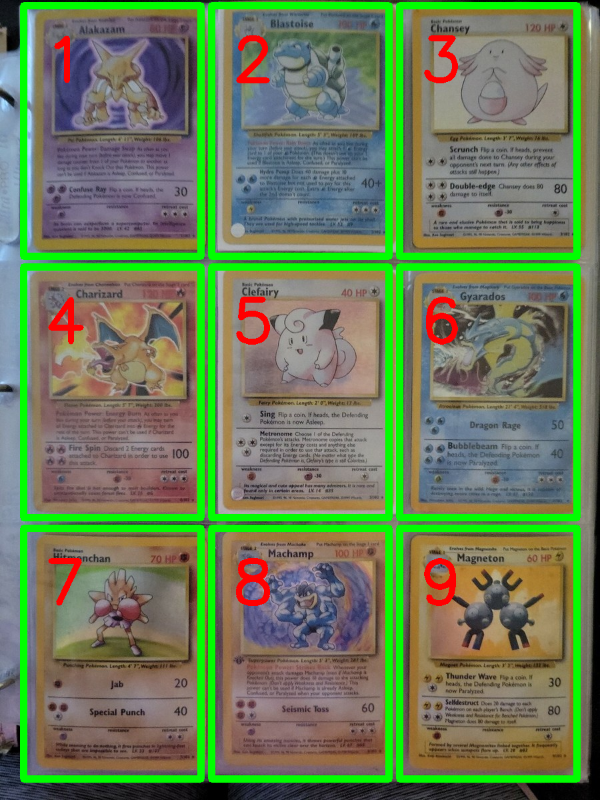

Cropped 9 cards


In [74]:
crops = detect_cards_pure_grid(
    "/content/binder_holos.jpg",   # ⚠️ mets le vrai nom
    rows=3, cols=3,
    top_bound=0.00,       # commencer très haut
    bottom_bound=0.98,    # jusqu'en bas
    left_bound=0.03,      # bords gauche/droite serrés
    right_bound=0.97,
    debug=True
)

In [75]:
import os
os.makedirs("/content/card_crops_holos", exist_ok=True)
for i, crop in enumerate(crops):
    cv2.imwrite(f"/content/card_crops_holos/card_{i+1}.png", crop)
print(f"✅ Sauvé {len(crops)} crops")

✅ Sauvé 9 crops


In [76]:
print("=" * 70)
print("SCAN DU CLASSEUR — BASE SET HOLOS")
print("=" * 70)

expected = ["Alakazam", "Blastoise", "Chansey",
            "Charizard", "Clefairy", "Gyarados",
            "Hitmonchan", "Machamp", "Magneton"]

results = []

for i, crop in enumerate(crops):
    print(f"\n{'─' * 70}")
    print(f"Card {i+1} (attendu : {expected[i]})")
    print(f"{'─' * 70}")

    crop_path = f"/content/card_crops_holos/card_{i+1}.png"
    crop_h = crop.shape[0]

    # OCR anglais
    ocr_result = ocr_en.predict(crop_path)
    texts = ocr_result[0].get("rec_texts", [])
    detected_name = extract_card_name(ocr_result, crop_h)

    if not detected_name:
        print("  ❌ Aucun nom détecté")
        results.append(None)
        continue

    parsed = parse_ocr_to_card_data(texts)
    parsed["name"] = detected_name

    print(f"  🎴 Nom : {detected_name}")
    print(f"  hp={parsed['hp']} | attacks={parsed['attacks'][:3]} | "
          f"abilities={parsed['abilities']} | set#={parsed['set_number']}")

    try:
        result = identify_card(parsed, verbose=False)
        if result:
            print(f"  ✅ MATCH: {result['id']} — {result['set']} "
                  f"#{result['number']} (score: {result['confidence']})")
            results.append(result)
        else:
            print("  ❌ Aucun match")
            results.append(None)
    except Exception as e:
        print(f"  ❌ ERROR: {e}")
        results.append(None)

# Résumé
print("\n" + "=" * 70)
print("RÉSUMÉ")
print("=" * 70)
matched = sum(1 for r in results if r)
print(f"\n{matched}/{len(results)} cartes identifiées\n")

for i, r in enumerate(results):
    exp = expected[i]
    if r:
        correct = "✓" if r["name"].lower() == exp.lower() else "?"
        print(f"  {i+1}. {r['name']:20s} → {r['set']} #{r['number']}  {correct}")
    else:
        print(f"  {i+1}. (attendu: {exp}) → ❌")

SCAN DU CLASSEUR — BASE SET HOLOS

──────────────────────────────────────────────────────────────────────
Card 1 (attendu : Alakazam)
──────────────────────────────────────────────────────────────────────
  🎴 Nom : Alakazam
  hp=None | attacks=['Alakazam', 'Mo Fakoops', 'Politooes Pewer'] | abilities=[] | set#=None
  ✅ MATCH: base1-1 — Base Set #1/102 (score: 30)

──────────────────────────────────────────────────────────────────────
Card 2 (attendu : Blastoise)
──────────────────────────────────────────────────────────────────────
  🎴 Nom : Blastoise
  hp=None | attacks=['Blastoise', 'Shottie Pokäman', 'Teso'] | abilities=[] | set#=None
  ✅ MATCH: base1-2 — Base Set #2/102 (score: 10)

──────────────────────────────────────────────────────────────────────
Card 3 (attendu : Chansey)
──────────────────────────────────────────────────────────────────────
  🎴 Nom : Chansey
  hp=120 | attacks=['Chansey', 'S Fusdasn', 'Ezg Pokemon'] | abilities=[] | set#=None
  ✅ MATCH: base1-3 — Base Set #